In [1]:
def get_model():
    nclass = 5
    inp = Input(shape=(187, 1))
    img_1 = Convolution1D(16, kernel_size=5, activation=activations.relu, padding="valid")(inp)
    img_1 = Convolution1D(16, kernel_size=5, activation=activations.relu, padding="valid")(img_1)
    img_1 = MaxPool1D(pool_size=2)(img_1)
    img_1 = Dropout(rate=0.1)(img_1)
    img_1 = Convolution1D(32, kernel_size=3, activation=activations.relu, padding="valid")(img_1)
    img_1 = Convolution1D(32, kernel_size=3, activation=activations.relu, padding="valid")(img_1)
    img_1 = MaxPool1D(pool_size=2)(img_1)
    img_1 = Dropout(rate=0.1)(img_1)
    img_1 = Convolution1D(32, kernel_size=3, activation=activations.relu, padding="valid")(img_1)
    img_1 = Convolution1D(32, kernel_size=3, activation=activations.relu, padding="valid")(img_1)
    img_1 = MaxPool1D(pool_size=2)(img_1)
    img_1 = Dropout(rate=0.1)(img_1)
    img_1 = Convolution1D(256, kernel_size=3, activation=activations.relu, padding="valid")(img_1)
    img_1 = Convolution1D(256, kernel_size=3, activation=activations.relu, padding="valid")(img_1)
    img_1 = GlobalMaxPool1D()(img_1)
    img_1 = Dropout(rate=0.2)(img_1)

    dense_1 = Dense(64, activation=activations.relu, name="dense_1")(img_1)
    dense_1 = Dense(64, activation=activations.relu, name="dense_2")(dense_1)
    dense_1 = Dense(nclass, activation=activations.softmax, name="dense_3_mitbih")(dense_1)

    model = models.Model(inputs=inp, outputs=dense_1)
    opt = optimizers.Adam(0.001)

    model.compile(optimizer=opt, loss=losses.sparse_categorical_crossentropy, metrics=['acc'])
    model.summary()
    return model

In [2]:
import pandas as pd
import numpy as np

from keras import optimizers, losses, activations, models
from keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler, ReduceLROnPlateau
from keras.layers import Dense, Input, Dropout, Convolution1D, MaxPool1D, GlobalMaxPool1D, GlobalAveragePooling1D, \
    concatenate
from sklearn.metrics import f1_score, accuracy_score




In [4]:
df_train = pd.read_csv("C:\\Users\\21629\\Documents\\PFA\\mitbih_train.csv\\mitbih_train.csv", header=None)
df_train = df_train.sample(frac=1)
df_test = pd.read_csv("C:\\Users\\21629\\Documents\\PFA\\mitbih_test.csv\\mitbih_test.csv", header=None)

Y = np.array(df_train[187].values).astype(np.int8)
X = np.array(df_train[list(range(187))].values)[..., np.newaxis]

Y_test = np.array(df_test[187].values).astype(np.int8)
X_test = np.array(df_test[list(range(187))].values)[..., np.newaxis]

def get_model():
    nclass = 5
    inp = Input(shape=(187, 1))
    img_1 = Convolution1D(16, kernel_size=5, activation=activations.relu, padding="valid")(inp)
    img_1 = Convolution1D(16, kernel_size=5, activation=activations.relu, padding="valid")(img_1)
    img_1 = MaxPool1D(pool_size=2)(img_1)
    img_1 = Dropout(rate=0.1)(img_1)
    img_1 = Convolution1D(32, kernel_size=3, activation=activations.relu, padding="valid")(img_1)
    img_1 = Convolution1D(32, kernel_size=3, activation=activations.relu, padding="valid")(img_1)
    img_1 = MaxPool1D(pool_size=2)(img_1)
    img_1 = Dropout(rate=0.1)(img_1)
    img_1 = Convolution1D(32, kernel_size=3, activation=activations.relu, padding="valid")(img_1)
    img_1 = Convolution1D(32, kernel_size=3, activation=activations.relu, padding="valid")(img_1)
    img_1 = MaxPool1D(pool_size=2)(img_1)
    img_1 = Dropout(rate=0.1)(img_1)
    img_1 = Convolution1D(256, kernel_size=3, activation=activations.relu, padding="valid")(img_1)
    img_1 = Convolution1D(256, kernel_size=3, activation=activations.relu, padding="valid")(img_1)
    img_1 = GlobalMaxPool1D()(img_1)
    img_1 = Dropout(rate=0.2)(img_1)

    dense_1 = Dense(64, activation=activations.relu, name="dense_1")(img_1)
    dense_1 = Dense(64, activation=activations.relu, name="dense_2")(dense_1)
    dense_1 = Dense(nclass, activation=activations.softmax, name="dense_3_mitbih")(dense_1)

    model = models.Model(inputs=inp, outputs=dense_1)
    opt = optimizers.Adam(0.001)

    model.compile(optimizer=opt, loss=losses.sparse_categorical_crossentropy, metrics=['acc'])
    model.summary()
    return model

model = get_model()
file_path = "baseline_cnn_mitbih.h5"
checkpoint = ModelCheckpoint(file_path, monitor='val_acc', verbose=1, save_best_only=True, mode='max')
early = EarlyStopping(monitor="val_acc", mode="max", patience=5, verbose=1)
redonplat = ReduceLROnPlateau(monitor="val_acc", mode="max", patience=3, verbose=2)
callbacks_list = [checkpoint, early, redonplat]  # early

model.fit(X, Y, epochs=1000, verbose=2, callbacks=callbacks_list, validation_split=0.1)
model.load_weights(file_path)

pred_test = model.predict(X_test)
pred_test = np.argmax(pred_test, axis=-1)

f1 = f1_score(Y_test, pred_test, average="macro")

print("Test f1 score : %s "% f1)

acc = accuracy_score(Y_test, pred_test)

print("Test accuracy score : %s "% acc)




Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 187, 1)]          0         
                                                                 
 conv1d (Conv1D)             (None, 183, 16)           96        
                                                                 
 conv1d_1 (Conv1D)           (None, 179, 16)           1296      
                                                                 
 max_pooling1d (MaxPooling1  (None, 89, 16)            0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 89, 16)            0         
                                                                 
 conv1d_2 (Conv1D)           (None, 87, 32)            1568      
                                                           

C:\Users\21629\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 2: val_acc improved from 0.93799 to 0.96003, saving model to baseline_cnn_mitbih.h5
2463/2463 - 34s - loss: 0.1944 - acc: 0.9457 - val_loss: 0.1483 - val_acc: 0.9600 - lr: 0.0010 - 34s/epoch - 14ms/step
Epoch 3/1000

Epoch 3: val_acc improved from 0.96003 to 0.96471, saving model to baseline_cnn_mitbih.h5
2463/2463 - 31s - loss: 0.1528 - acc: 0.9579 - val_loss: 0.1359 - val_acc: 0.9647 - lr: 0.0010 - 31s/epoch - 13ms/step
Epoch 4/1000

Epoch 4: val_acc improved from 0.96471 to 0.97430, saving model to baseline_cnn_mitbih.h5
2463/2463 - 30s - loss: 0.1322 - acc: 0.9639 - val_loss: 0.0916 - val_acc: 0.9743 - lr: 0.0010 - 30s/epoch - 12ms/step
Epoch 5/1000

Epoch 5: val_acc improved from 0.97430 to 0.97590, saving model to baseline_cnn_mitbih.h5
2463/2463 - 32s - loss: 0.1193 - acc: 0.9674 - val_loss: 0.0830 - val_acc: 0.9759 - lr: 0.0010 - 32s/epoch - 13ms/step
Epoch 6/1000

Epoch 6: val_acc improved from 0.97590 to 0.97773, saving model to baseline_cnn_mitbih.h5
2463/2463 - 31s -

In [5]:
history = model.fit(X, Y, epochs=1000, verbose=2, callbacks=callbacks_list, validation_split=0.1)


Epoch 1/1000

Epoch 1: val_acc did not improve from 0.98904
2463/2463 - 29s - loss: 0.0415 - acc: 0.9875 - val_loss: 0.0415 - val_acc: 0.9890 - lr: 1.0000e-05 - 29s/epoch - 12ms/step
Epoch 2/1000

Epoch 2: val_acc did not improve from 0.98904
2463/2463 - 31s - loss: 0.0406 - acc: 0.9879 - val_loss: 0.0414 - val_acc: 0.9890 - lr: 1.0000e-05 - 31s/epoch - 13ms/step
Epoch 3/1000

Epoch 3: val_acc did not improve from 0.98904
2463/2463 - 32s - loss: 0.0410 - acc: 0.9873 - val_loss: 0.0413 - val_acc: 0.9889 - lr: 1.0000e-05 - 32s/epoch - 13ms/step
Epoch 4/1000

Epoch 4: val_acc improved from 0.98904 to 0.98915, saving model to baseline_cnn_mitbih.h5
2463/2463 - 32s - loss: 0.0394 - acc: 0.9876 - val_loss: 0.0417 - val_acc: 0.9892 - lr: 1.0000e-05 - 32s/epoch - 13ms/step
Epoch 5/1000


C:\Users\21629\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 5: val_acc improved from 0.98915 to 0.98926, saving model to baseline_cnn_mitbih.h5
2463/2463 - 31s - loss: 0.0402 - acc: 0.9877 - val_loss: 0.0416 - val_acc: 0.9893 - lr: 1.0000e-05 - 31s/epoch - 13ms/step
Epoch 6/1000

Epoch 6: val_acc did not improve from 0.98926
2463/2463 - 31s - loss: 0.0392 - acc: 0.9882 - val_loss: 0.0420 - val_acc: 0.9889 - lr: 1.0000e-05 - 31s/epoch - 13ms/step
Epoch 7/1000

Epoch 7: val_acc improved from 0.98926 to 0.98938, saving model to baseline_cnn_mitbih.h5
2463/2463 - 32s - loss: 0.0389 - acc: 0.9880 - val_loss: 0.0411 - val_acc: 0.9894 - lr: 1.0000e-05 - 32s/epoch - 13ms/step
Epoch 8/1000

Epoch 8: val_acc improved from 0.98938 to 0.98961, saving model to baseline_cnn_mitbih.h5
2463/2463 - 31s - loss: 0.0394 - acc: 0.9876 - val_loss: 0.0412 - val_acc: 0.9896 - lr: 1.0000e-05 - 31s/epoch - 13ms/step
Epoch 9/1000

Epoch 9: val_acc did not improve from 0.98961
2463/2463 - 32s - loss: 0.0391 - acc: 0.9878 - val_loss: 0.0410 - val_acc: 0.9894 - lr: 1

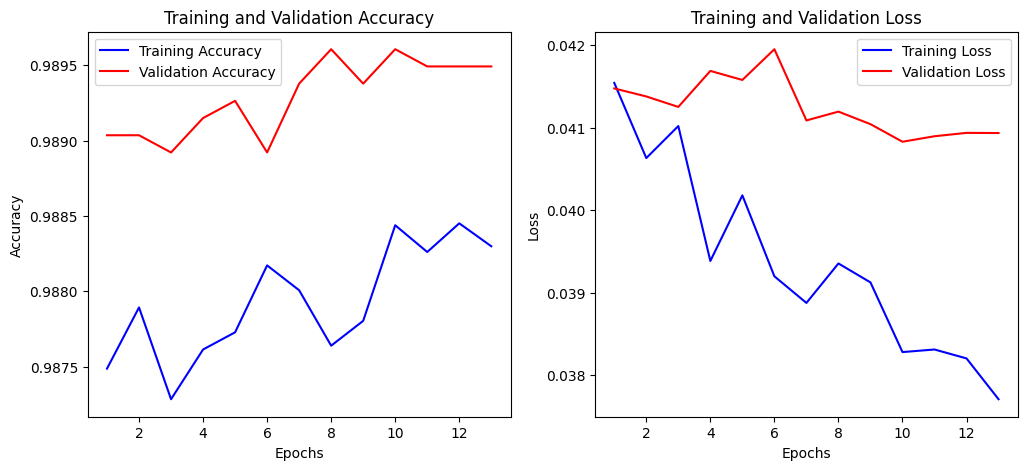

In [6]:
import matplotlib.pyplot as plt

# Récupérer les valeurs de l'historique
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# 📌 Tracer la courbe d'accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# 📌 Tracer la courbe de perte (loss)
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()
